In [4]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
def ach_price_heatmap(path):
    # json 파일 불러오기
    with open(path, "r", encoding="utf-8") as json_file:
        game_data = json.load(json_file)

    # 기준 값 리스트
    thresholds = [3.0, 10.0, 30.0, 50.0, 75.0]
    
    # 데이터 프레임 열과 행 변환
    df = pd.DataFrame(game_data)
    df = df.T
    df = df[df["total_ach"] != 0]
    df = df.drop(columns=['code'])
    df = df.drop(columns=['link'])
    df = df.drop(columns=['ach_list'])

    # NaN 값이 있는 행 제거
    df.fillna(0, inplace=True)

    # 각 기준 값 이상인 개수를 count하고 컬럼으로 추가
    for t in thresholds:
        df[f"count_{t}"] = df["ach_ratio_list"].apply(lambda x: sum(ach >= t for ach in x))

    df = df.drop(columns=['ach_ratio_list'])

    # 가격에 따라 고가, 중가, 저가, 무료 게임으로 분리
    high_price_games = df[df['price'] > 50000]
    middle_price_games = df[(df['price'] > 25000) & (df['price'] < 50000)]
    low_price_games = df[(df['price'] > 0) & (df['price'] < 25000)]
    free_games = df[df['price'] == 0]

    high_price_games = high_price_games.drop(columns=['price'])
    middle_price_games = middle_price_games.drop(columns=['price'])
    low_price_games = low_price_games.drop(columns=['price'])
    free_games = free_games.drop(columns=['price'])

    price_list = {'high_price_games':high_price_games,
                'middle_price_games':middle_price_games,
                'low_price_games':low_price_games,
                'free_games':free_games}
    
    # 2행 2열 subplot 생성
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

    # 딕셔너리에서 key(게임 이름), value(데이터프레임) 가져오기
    for idx, (game_name, game_df) in enumerate(price_list.items()):
        row, col = divmod(idx, 2)  # idx를 2로 나눈 몫(row)과 나머지(col) 계산
        sns.heatmap(game_df.corr(), annot=True, ax=axes[row, col], cmap="coolwarm", fmt=".2f")  # 히트맵 그리기
        axes[row, col].set_title(game_name)  # 서브플롯 제목을 게임 이름으로 설정

    plt.tight_layout()  # 레이아웃 자동 조정
    plt.show()

def ach_total_heatmap(path):
    # json 파일 불러오기
    with open(path, "r", encoding="utf-8") as json_file:
        game_data = json.load(json_file)

    # 데이터 프레임 열과 행 변환
    df = pd.DataFrame(game_data)
    df = df.T
    df = df[df["total_ach"] != 0]
    df = df.drop(columns=['code'])
    df = df.drop(columns=['link'])
    df = df.drop(columns=['ach_list'])
    df = df.drop(columns=['ach_ratio_list'])

    # NaN 값이 있는 행 제거
    df.fillna(0, inplace=True)

    # 히트맵 시각화
    plt.figure(figsize=(8, 6))
    sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Feature Correlation Heatmap")
    plt.show()    

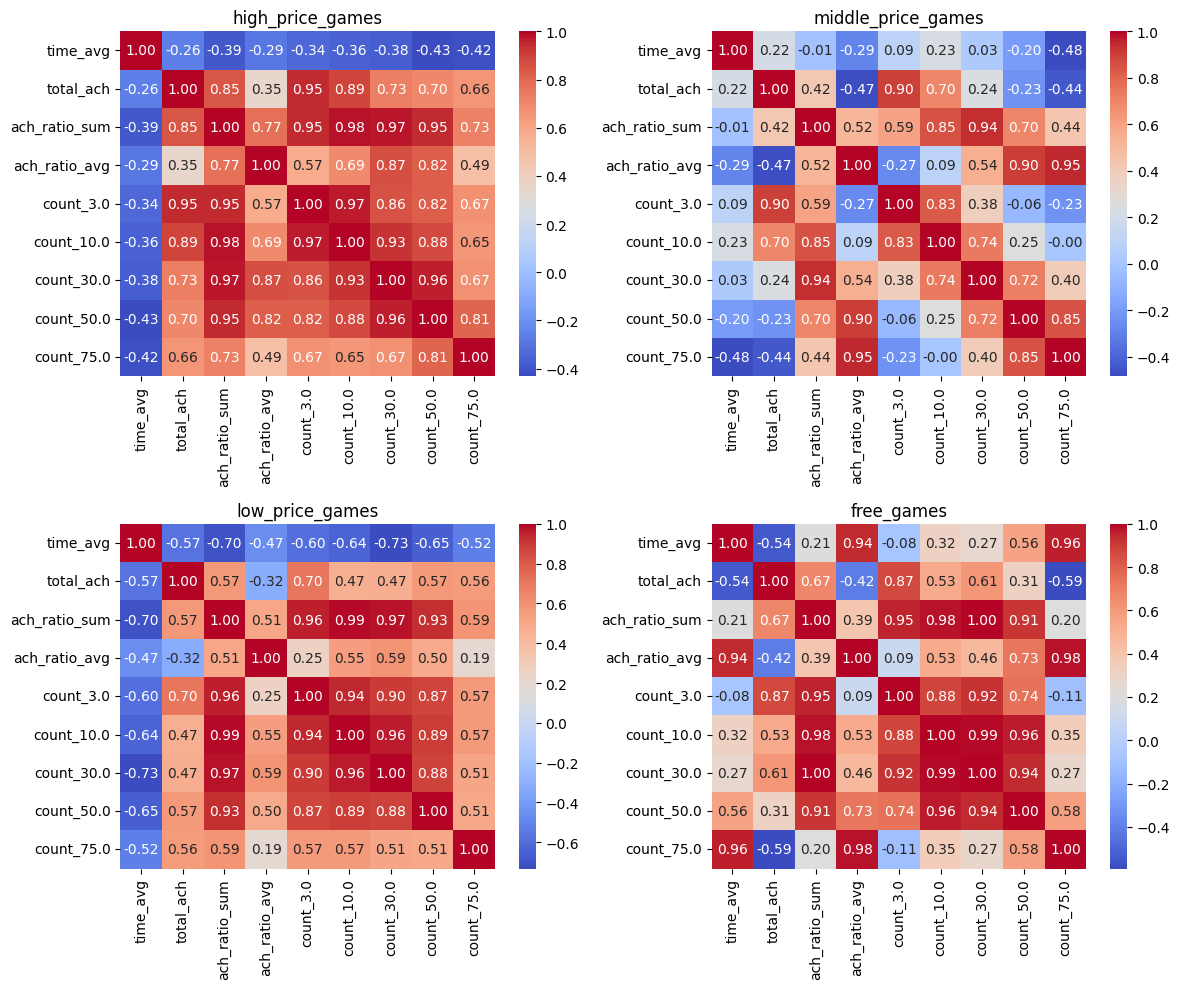

In [20]:
ach_price_heatmap('steam_open_multi.json')